<a href="https://colab.research.google.com/github/Yonatankinfe/chatterbox-tts/blob/main/ResembleAI_Chatterbox_(TTS_%2B_Voice_Clone).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Chatterbox TTS Google Colab Script
==================================

A comprehensive script for text-to-speech generation and voice cloning using
Chatterbox TTS in Google Colab environment.


---


- Author: ukr
- License: MIT
- Repository: https://github.com/notebook-nexus/chatterbox-tts-colab


---


Features:
- Automatic dependency installation with fallbacks
- Voice cloning from audio samples
- Long text processing with chunking
- Google Drive integration
- Robust error handling
- GPU/CPU automatic detection



---



In [1]:
# Emergency cleanup cell - run this if still having issues
!pip uninstall -y torch torchvision torchaudio transformers chatterbox-tts -y
!pip cache purge
print("Cleanup complete. Now run Cell 1.")

Found existing installation: torch 2.6.0+cu124
Uninstalling torch-2.6.0+cu124:
  Successfully uninstalled torch-2.6.0+cu124
Found existing installation: torchvision 0.21.0+cu124
Uninstalling torchvision-0.21.0+cu124:
  Successfully uninstalled torchvision-0.21.0+cu124
Found existing installation: torchaudio 2.6.0+cu124
Uninstalling torchaudio-2.6.0+cu124:
  Successfully uninstalled torchaudio-2.6.0+cu124
Found existing installation: transformers 4.53.2
Uninstalling transformers-4.53.2:
  Successfully uninstalled transformers-4.53.2
Files removed: 0
Cleanup complete. Now run Cell 1.


Cell 1: Installation and Dependencies

---
Run this cell first, then WAIT for kernel restart

In [2]:
import subprocess
import sys
import os
from pathlib import Path

def run_command(command, description=""):
    """Run a command and handle errors gracefully"""
    print(f"Running: {description if description else command}")
    try:
        result = subprocess.run(command, shell=True, capture_output=True, text=True)
        if result.returncode != 0:
            print(f"Warning: {description} failed with return code {result.returncode}")
            print(f"stderr: {result.stderr}")
            print(f"stdout: {result.stdout}")
            return False
        else:
            print(f"Success: {description}")
            return True
    except Exception as e:
        print(f"Error running command: {e}")
        return False

print(f"Python version: {sys.version}")

# Update pip first
run_command("pip install --upgrade pip", "Upgrading pip")

# CRITICAL: Complete uninstall of all related packages
print("🧹 Cleaning existing installations...")
run_command("pip uninstall -y torch torchvision torchaudio transformers chatterbox-tts accelerate huggingface-hub diffusers torchao perth resemble-perth", "Removing all related packages")

# CRITICAL FIX: Install PyTorch from PyPI (NOT from CPU index) to get full build with torch.fx
print("📦 Installing PyTorch 2.5.0 from PyPI...")
run_command(
    "pip install torch==2.5.0 torchaudio==2.5.0",
    "Installing PyTorch 2.5.0 (full build with torch.fx)"
)

# Install exact versions required by Chatterbox
print("📦 Installing Chatterbox dependencies...")
run_command("pip install transformers==4.46.3", "Installing transformers 4.46.3")
run_command("pip install diffusers==0.29.0", "Installing diffusers 0.29.0")
run_command("pip install huggingface_hub>=0.23.0", "Installing huggingface_hub")
run_command("pip install accelerate>=0.25.0", "Installing accelerate")

# Install git-lfs
run_command("apt update && apt install -y git-lfs", "Installing git-lfs")

# Install other required dependencies
print("📦 Installing audio processing libraries...")
run_command("pip install 'numpy>=1.24.0,<1.26.0' librosa==0.11.0 safetensors soundfile scipy", "Installing dependencies")

# CRITICAL FIX: Install resemble-perth (not just 'perth')
print("📦 Installing resemble-perth (watermarker)...")
run_command("pip install resemble-perth", "Installing resemble-perth watermarker")

# Install s3tokenizer and conformer
print("📦 Installing s3tokenizer and conformer...")
run_command("pip install s3tokenizer conformer", "Installing s3tokenizer and conformer")

# Install chatterbox-tts without dependencies
print("📦 Installing Chatterbox TTS...")
run_command("pip install chatterbox-tts --no-deps", "Installing Chatterbox TTS without dependencies")

# Fix protobuf
print("🔧 Fixing protobuf...")
run_command("pip uninstall -y protobuf", "Uninstalling protobuf")
run_command("pip install protobuf==3.20.3", "Installing protobuf 3.20.3")

print("\n✅ Installation complete!")
print("🔄 Restarting kernel...")
print("⚠️  WAIT for kernel restart, then run Cell 2!")
get_ipython().kernel.do_shutdown(True)

Python version: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
Running: Upgrading pip
Success: Upgrading pip
🧹 Cleaning existing installations...
Running: Removing all related packages
Success: Removing all related packages
📦 Installing PyTorch 2.5.0 from PyPI...
Running: Installing PyTorch 2.5.0 (full build with torch.fx)
Success: Installing PyTorch 2.5.0 (full build with torch.fx)
📦 Installing Chatterbox dependencies...
Running: Installing transformers 4.46.3
Success: Installing transformers 4.46.3
Running: Installing diffusers 0.29.0
Success: Installing diffusers 0.29.0
Running: Installing huggingface_hub
Success: Installing huggingface_hub
Running: Installing accelerate
Success: Installing accelerate
Running: Installing git-lfs
Success: Installing git-lfs
📦 Installing audio processing libraries...
Running: Installing dependencies
Success: Installing dependencies
📦 Installing resemble-perth (watermarker)...
Running: Installing resemble-perth watermarker
Success: Installing resem

{'status': 'ok', 'restart': True}

Cell 2: Verify Installation

---


Run this cell after kernel restart

In [1]:
# Verify installation - import in specific order to avoid circular imports
import sys
print("🔍 Verifying installation...\n")

# Import torch first
try:
    import torch
    import torchaudio
    print(f"✅ PyTorch {torch.__version__} imported successfully")
    print(f"   CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"   CUDA version: {torch.version.cuda}")
except ImportError as e:
    print(f"❌ PyTorch import error: {e}")
    print("   Please run Cell 1 again")
    sys.exit(1)

# Check if torchvision is installed (it shouldn't be)
try:
    import torchvision
    print(f"⚠️  Warning: torchvision {torchvision.__version__} is installed")
    print("   This may cause conflicts. Consider uninstalling it.")
except ImportError:
    print("✅ torchvision not installed (good - not needed for Chatterbox)")

# Import transformers
try:
    import transformers
    print(f"✅ Transformers {transformers.__version__} imported successfully")
except ImportError as e:
    print(f"❌ Transformers import error: {e}")
    sys.exit(1)

# Import Chatterbox TTS - this is the critical test
try:
    from chatterbox.tts import ChatterboxTTS
    print("✅ ChatterboxTTS imported successfully")
    print("\n🎉 All imports successful! You can proceed to Cell 3.")
except Exception as e:
    print(f"❌ ChatterboxTTS import error: {e}")
    print("\n🔧 Troubleshooting:")
    print("   1. Make sure kernel was restarted after Cell 1")
    print("   2. If error persists, run this command in a new cell:")
    print("      !pip uninstall -y torchvision")
    print("   3. Then restart kernel and try Cell 2 again")
    sys.exit(1)

🔍 Verifying installation...

✅ PyTorch 2.5.0+cu124 imported successfully
   CUDA available: True
   CUDA version: 12.4
✅ torchvision not installed (good - not needed for Chatterbox)
✅ Transformers 4.46.3 imported successfully
✅ ChatterboxTTS imported successfully

🎉 All imports successful! You can proceed to Cell 3.


Cell 3: Google Drive Setup

---


Run this cell to set up Google Drive

In [ ]:
from google.colab import drive
import os

def setup_drive():
    try:
        drive.mount('/content/drive')
        drive_path = '/content/drive/MyDrive/Chatterbox'
        os.makedirs(drive_path, exist_ok=True)
        print(f"✅ Drive setup complete: {drive_path}")
        return drive_path
    except Exception as e:
        print(f"❌ Drive setup failed: {e}")
        return None

DRIVE_PATH = setup_drive()

Mounted at /content/drive
✅ Drive setup complete: /content/drive/MyDrive/Chatterbox


Cell 4: Model Loading with Advanced Configuration

---


Load the Chatterbox model

In [2]:
import torch
from chatterbox.tts import ChatterboxTTS

def load_model():
    try:
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
        print(f"Loading model on device: {device}")

        model = ChatterboxTTS.from_pretrained(device=device)
        print("✅ Model loaded successfully")
        return model

    except Exception as e:
        print(f"❌ Model loading failed: {e}")
        print("Trying CPU fallback...")

        try:
            model = ChatterboxTTS.from_pretrained(device="cpu")
            print("✅ Model loaded successfully on CPU")
            return model
        except Exception as e2:
            print(f"❌ CPU fallback also failed: {e2}")
            raise e2

model = load_model()

Loading model on device: cuda


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


ve.safetensors:   0%|          | 0.00/5.70M [00:00<?, ?B/s]

t3_cfg.safetensors:   0%|          | 0.00/2.13G [00:00<?, ?B/s]

s3gen.safetensors:   0%|          | 0.00/1.06G [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

conds.pt:   0%|          | 0.00/107k [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/diffusers/models/lora.py:393: FutureWarning: `LoRACompatibleLinear` is deprecated and will be removed in version 1.0.0. Use of `LoRACompatibleLinear` is deprecated. Please switch to PEFT backend by installing PEFT: `pip install peft`.
  deprecate("LoRACompatibleLinear", "1.0.0", deprecation_message)


loaded PerthNet (Implicit) at step 250,000
✅ Model loaded successfully


/usr/local/lib/python3.11/dist-packages/perth/perth_net/perth_net_implicit/checkpoint_manager.py:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(ckpts[-1

Cell 5: Advanced Controls Configuration

---


Configure advanced parameters for voice generation

In [ ]:
class ChatterboxConfig:
    def __init__(self):
        self.exaggeration = 0.5
        self.cfg_weight = 0.5
        self.max_chunk_words = 50
        self.voice_sample_path = None

    def get_preset(self, preset_name):
        presets = {

            "neutral":      {"exaggeration": 0.5, "cfg_weight": 0.5},
            "calm":         {"exaggeration": 0.3, "cfg_weight": 0.6},
            "expressive":   {"exaggeration": 0.7, "cfg_weight": 0.4},
            "dramatic":     {"exaggeration": 1.0, "cfg_weight": 0.3},
            "storytelling": {"exaggeration": 0.8, "cfg_weight": 0.4},
            "audiobook":    {"exaggeration": 0.4, "cfg_weight": 0.6},
            "fast_speaker": {"exaggeration": 0.6, "cfg_weight": 0.3},
            # ✅ NEW: mid-30s adult, slightly above mid speed
            "mid30s":       {"exaggeration": 0.45, "cfg_weight": 0.55},


          }
        return presets.get(preset_name, presets["neutral"])

config = ChatterboxConfig()

# ✅ Apply the mid-30s preset
settings = config.get_preset("mid30s")
config.exaggeration = settings["exaggeration"]
config.cfg_weight   = settings["cfg_weight"]

# Speed multiplier: 1.0 = normal, 1.15 = mid-to-fast range
config.speed_factor = 1.15  # tweak between 1.1–1.25 to taste

print(f"🎛️ Current settings:")
print(f"   Exaggeration: {config.exaggeration}  (lower = more grounded/mature)")
print(f"   CFG Weight:   {config.cfg_weight}  (higher = steadier delivery)")
print(f"   Speed factor: {config.speed_factor}x")
print(f"   Chunk size:   {config.max_chunk_words} words")

🎛️ Current settings:
   Exaggeration: 0.6
   CFG Weight: 0.4
   Chunk size: 50 words


Cell 6: Voice Sample Setup (Optional)

---


Set up voice cloning with your own audio

In [ ]:
def setup_voice_cloning():
    print("🎤 VOICE CLONING SETUP")
    print("=" * 50)
    print("For best results, your voice sample should:")
    print("• Be at least 10 seconds long (ideally 15-30 seconds)")
    print("• Be in WAV format")
    print("• Have clear, consistent audio quality")
    print("• Contain natural speech (avoid reading lists/monotone)")
    print("• Be recorded in a quiet environment")
    print("• Match the speaking style you want to generate")
    print()

    if DRIVE_PATH:
        sample_path = f"{DRIVE_PATH}/audio.mp3"
        print(f"📁 Upload your voice sample to: {sample_path}")
        print("   Or use Google Colab's file upload feature")

        if os.path.exists(sample_path):
            print(f"✅ Voice sample found: {sample_path}")
            config.voice_sample_path = sample_path
            return sample_path
        else:
            print(f"⚠️  No voice sample found at {sample_path}")
            print("   Voice cloning will be disabled")
            return None
    else:
        print("❌ Google Drive not mounted - voice cloning disabled")
        return None

voice_sample = setup_voice_cloning()

🎤 VOICE CLONING SETUP
For best results, your voice sample should:
• Be at least 10 seconds long (ideally 15-30 seconds)
• Be in WAV format
• Have clear, consistent audio quality
• Contain natural speech (avoid reading lists/monotone)
• Be recorded in a quiet environment
• Match the speaking style you want to generate

📁 Upload your voice sample to: /content/drive/MyDrive/Chatterbox/audio.mp3
   Or use Google Colab's file upload feature
✅ Voice sample found: /content/drive/MyDrive/Chatterbox/audio.mp3


Cell 7: Text Processing Functions


---


Helper functions for text processing

In [ ]:
def split_into_chunks(text, max_words=100):
    sentences = text.strip().replace('\n', ' ').split('.')
    sentences = [s.strip() for s in sentences if s.strip()]

    chunks = []
    current_chunk = ""
    current_word_count = 0

    for sentence in sentences:
        sentence_words = sentence.split()

        if current_word_count + len(sentence_words) > max_words and current_chunk:
            chunks.append(current_chunk.strip() + ".")
            current_chunk = sentence
            current_word_count = len(sentence_words)
        else:
            if current_chunk:
                current_chunk += ". " + sentence
            else:
                current_chunk = sentence
            current_word_count += len(sentence_words)

    if current_chunk:
        chunks.append(current_chunk.strip() + ".")

    return chunks

def estimate_processing_time(text, words_per_minute=150):
    word_count = len(text.split())
    estimated_minutes = word_count / words_per_minute
    return word_count, estimated_minutes

sample_text = """
This is a test of the enhanced Chatterbox TTS system.
The system now includes advanced controls for voice quality and expression.
You can adjust parameters like exaggeration and CFG weight for different effects.
"""

chunks = split_into_chunks(sample_text, config.max_chunk_words)
word_count, time_est = estimate_processing_time(sample_text)

print(f"📊 Text Analysis:")
print(f"   Total words: {word_count}")
print(f"   Estimated time: {time_est:.1f} minutes")
print(f"   Number of chunks: {len(chunks)}")
print(f"   Chunk preview: '{chunks[0][:50]}...'")

📊 Text Analysis:
   Total words: 33
   Estimated time: 0.2 minutes
   Number of chunks: 1
   Chunk preview: 'This is a test of the enhanced Chatterbox TTS syst...'


Cell 8: Main TTS Generation

---


Generate speech with your configured settings

In [ ]:
def apply_speed(wav_tensor, sample_rate, speed_factor):
    """Stretch/compress audio tempo without changing pitch."""
    if abs(speed_factor - 1.0) < 0.01:
        return wav_tensor  # no change needed
    # Resample trick: upsample then downsample to shift speed
    orig_len   = wav_tensor.shape[-1]
    target_len = int(orig_len / speed_factor)
    resampled  = torchaudio.functional.resample(
        wav_tensor,
        orig_freq=sample_rate,
        new_freq=int(sample_rate * speed_factor)
    )
    return resampled

def generate_speech(text, config, model, output_filename="generated_speech.wav"):
    print("🎙️ STARTING SPEECH GENERATION")
    print("=" * 50)

    chunks = split_into_chunks(text, config.max_chunk_words)
    word_count, time_est = estimate_processing_time(text)
    speed_factor = getattr(config, "speed_factor", 1.0)

    print(f"📝 Text: {word_count} words, {len(chunks)} chunks")
    print(f"⏱️  Estimated time: {time_est:.1f} minutes")
    print(f"🎛️ Settings: exaggeration={config.exaggeration}, "
          f"cfg_weight={config.cfg_weight}, speed={speed_factor}x")

    if config.voice_sample_path and os.path.exists(config.voice_sample_path):
        print(f"🎤 Using voice cloning: {config.voice_sample_path}")
    else:
        print("🤖 Using default voice (no cloning)")

    print("\n🔄 Processing chunks...")
    wav_tensors = []

    for i, chunk in enumerate(chunks):
        print(f"  Chunk {i+1}/{len(chunks)}: '{chunk[:50]}...'")
        try:
            gen_params = {
                "text":         chunk,
                "exaggeration": config.exaggeration,
                "cfg_weight":   config.cfg_weight,
            }
            if config.voice_sample_path and os.path.exists(config.voice_sample_path):
                gen_params["audio_prompt_path"] = config.voice_sample_path

            wav = model.generate(**gen_params)

            # ✅ Apply speed adjustment per chunk
            if speed_factor != 1.0:
                wav = apply_speed(wav, model.sr, speed_factor)

            wav_tensors.append(wav)

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        except Exception as e:
            print(f"  ❌ Error in chunk {i+1}: {e}")
            continue

    if wav_tensors:
        print(f"\n💾 Saving {len(wav_tensors)} audio chunks...")
        full_audio = torch.cat(wav_tensors, dim=1)

        if DRIVE_PATH:
            output_path = f"{DRIVE_PATH}/{output_filename}"
            torchaudio.save(output_path, full_audio, model.sr)
            print(f"✅ Saved to Drive: {output_path}")
            local_path = f"/content/{output_filename}"
            torchaudio.save(local_path, full_audio, model.sr)
            return output_path, local_path
        else:
            local_path = f"/content/{output_filename}"
            torchaudio.save(local_path, full_audio, model.sr)
            print(f"✅ Saved locally: {local_path}")
            return local_path, local_path
    else:
        print("❌ No audio was generated")
        return None, None

your_text = """
Welcome to the enhanced Chatterbox TTS system!
This demonstration showcases the advanced voice synthesis capabilities with customizable parameters.
You can adjust the exaggeration level to make the voice more or less expressive.
The CFG weight parameter controls how closely the system follows the reference audio style.
This technology opens up exciting possibilities for content creation, accessibility, and entertainment.
"""

output_path, local_path = generate_speech(your_text, config, model)

🎙️ STARTING SPEECH GENERATION
📝 Text: 58 words, 2 chunks
⏱️  Estimated time: 0.4 minutes
🎛️ Settings: exaggeration=0.6, cfg_weight=0.4
🎤 Using voice cloning: /content/drive/MyDrive/Chatterbox/audio.mp3

🔄 Processing chunks...
Processing chunk 1/2: 'Welcome to the enhanced Chatterbox TTS system! Thi...'


/usr/local/lib/python3.11/dist-packages/chatterbox/tts.py:184: UserWarning: PySoundFile failed. Trying audioread instead.
  s3gen_ref_wav, _sr = librosa.load(wav_fpath, sr=S3GEN_SR)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)

/usr/lib/python3.11/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)
LlamaModel is using LlamaSdpaAttention, but `torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Trans

Processing chunk 2/2: 'This technology opens up exciting possibilities fo...'


/usr/local/lib/python3.11/dist-packages/chatterbox/tts.py:184: UserWarning: PySoundFile failed. Trying audioread instead.
  s3gen_ref_wav, _sr = librosa.load(wav_fpath, sr=S3GEN_SR)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)

/usr/lib/python3.11/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)
Sampling:  16%|█▌        | 161/1000 [00:05<00:27, 30.44it/s]



💾 Saving 2 audio chunks...
✅ Audio saved to: /content/drive/MyDrive/Chatterbox/generated_speech.wav
📱 Local copy: /content/generated_speech.wav


Cell 9: Audio Playback and Analysis

---


Play and analyze the generated audio

🔊 Playing audio: /content/generated_speech.wav


📊 Audio Analysis:
   Duration: 20.80 seconds
   Sample Rate: 24000 Hz
   Channels: 1


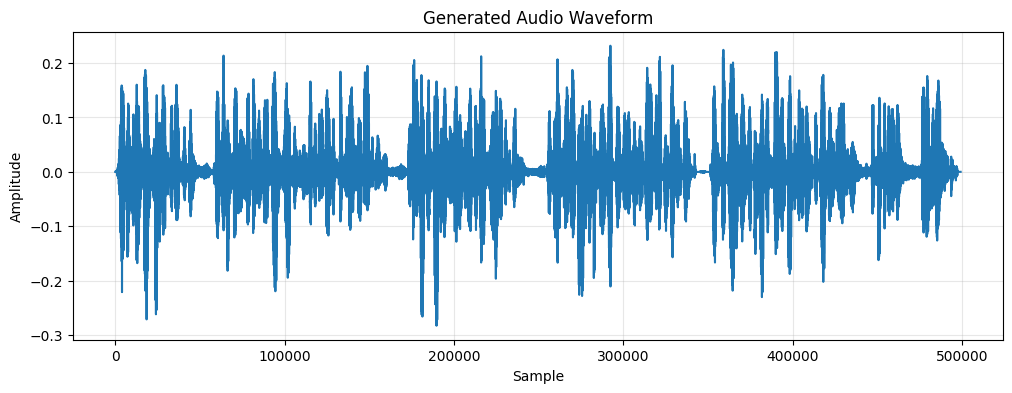

In [ ]:
import IPython.display as ipd
import matplotlib.pyplot as plt
import numpy as np

def play_and_analyze_audio(audio_path):
    if not audio_path or not os.path.exists(audio_path):
        print("❌ No audio file to play")
        return

    print(f"🔊 Playing audio: {audio_path}")

    ipd.display(ipd.Audio(audio_path))

    try:
        waveform, sample_rate = torchaudio.load(audio_path)
        duration = waveform.shape[1] / sample_rate

        print(f"📊 Audio Analysis:")
        print(f"   Duration: {duration:.2f} seconds")
        print(f"   Sample Rate: {sample_rate} Hz")
        print(f"   Channels: {waveform.shape[0]}")

        plt.figure(figsize=(12, 4))
        plt.plot(waveform[0].numpy())
        plt.title("Generated Audio Waveform")
        plt.xlabel("Sample")
        plt.ylabel("Amplitude")
        plt.grid(True, alpha=0.3)
        plt.show()

    except Exception as e:
        print(f"❌ Error analyzing audio: {e}")

if local_path:
    play_and_analyze_audio(local_path)

Cell 10: Parameter Experimentation

---


Test different parameter combinations

In [ ]:
def experiment_with_parameters(text, model):
    experiments = [
        {"name": "Neutral", "exaggeration": 0.5, "cfg_weight": 0.5},
        {"name": "Expressive", "exaggeration": 0.8, "cfg_weight": 0.4},
        {"name": "Calm", "exaggeration": 0.3, "cfg_weight": 0.6},
        {"name": "Dramatic", "exaggeration": 1.0, "cfg_weight": 0.3},
    ]

    short_text = "Hello! This is a test of different voice parameters."

    print("🧪 PARAMETER EXPERIMENTS")
    print("=" * 50)

    for exp in experiments:
        print(f"\n🎭 Testing: {exp['name']}")
        print(f"   Exaggeration: {exp['exaggeration']}, CFG Weight: {exp['cfg_weight']}")

        try:
            gen_params = {
                "text": short_text,
                "exaggeration": exp['exaggeration'],
                "cfg_weight": exp['cfg_weight']
            }

            if config.voice_sample_path and os.path.exists(config.voice_sample_path):
                gen_params["audio_prompt_path"] = config.voice_sample_path

            wav = model.generate(**gen_params)

            filename = f"experiment_{exp['name'].lower()}.wav"
            filepath = f"/content/{filename}"
            torchaudio.save(filepath, wav, model.sr)

            print(f"   ✅ Generated: {filename}")
            print(f"   🔊 Playing...")
            ipd.display(ipd.Audio(filepath))

        except Exception as e:
            print(f"   ❌ Error: {e}")

experiment_with_parameters("Hello! This is a test of different voice parameters.", model)